In [1]:
from collections import defaultdict

import nibabel

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [2]:
subject_ids = set(range(1, 34))
# subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

# subject_ids = [13]

run_ids = list(range(1,5))
run_ids = [5]

print(subject_ids, run_ids)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26} [5]


In [3]:
labels = pd.read_csv(f"labels/motor/labels_{1}.csv")

diff = np.where(np.diff(labels["response"]) != 0)[0]
times_index = np.insert(diff, 0, 0)

values = labels["response"][diff].values
onsets = labels["response time"][times_index[:-1]].values
d_times = labels["response time"][times_index].values

durations = d_times[1:] - d_times[:-1]

onsets

array([  3921,  22328,  46488,  76267,  96074, 120635, 143827, 169371,
       174323, 175857, 193731])

In [4]:
Subject(list(subject_ids)[0], run_ids).sample_mask

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97, 100, 101])

In [5]:

subject_ids

{1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26}

In [6]:
#subject_ids = set(range(27, 34))  # override, run on SCZ

In [7]:
len(subject_ids)

26

In [6]:

skipped = []
global_z_map = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
        dataset.load()

        images, _, _ = dataset.get_data()

        sample_mask = dataset.sample_mask
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    labels = pd.read_csv(f"labels/motor/labels_{subject}.csv")

    diff = np.where(np.diff(labels["response"]) != 0)[0]
    times_index = np.insert(diff, 0, 0)

    values = labels["response"][diff].values
    onsets = labels["response time"][times_index[:-1]].values / 1000
    d_times = labels["response time"][times_index].values

    durations = (d_times[1:] - d_times[:-1]) / 1000


    events = pd.DataFrame(
        {'onset': onsets,
         'trial_type': values,
         'duration': durations}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              smoothing_fwhm=4,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
    # fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    glm_contrast_vector = contrasts["1"] - contrasts["0"]

    z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")

    global_z_map.append(z_score)




C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\918988288.py:46: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\918988288.py:46: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\918988288.py:46: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\918988288.py:46: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)


In [7]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [33]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

if False:  # avoid plot each time

    for contrast_name, images in global_z_map.items():
        for z_score, subject in zip(images, z_map_subjects):

            clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="bonferroni", cluster_threshold=5)
            cut_coords_list = [
                (0, 0, 0),
                (10, -20, 30),
                (-15, 10, 45),
            ]

            n_coords = len(cut_coords_list)

            fig, axes = plt.subplots(
                n_coords, 1,
                figsize=(15, 4 * n_coords)
            )

            fig.suptitle(contrast_name, fontweight="bold")

            bg_run = MRI(subject, 1)

            for ax, coords in zip(axes, cut_coords_list):
                plot_stat_map(
                    clean_z,
                    display_mode='ortho',
                    cut_coords=coords,
                    axes=ax,
                    bg_img=bg_run.background,
                    title=f"Ortho @ {coords}",
                    colorbar=True
                )

            plt.tight_layout()
            fname = contrast_name.replace(' ', '_').replace('>', 'over')
            plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [7]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [9]:
mni_regions = []

for z_score in global_z_map:
    clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
#    clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=5)
    table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)

    pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
        print(table)

    for p in pos:
        try:
            projected_coords = atlas.project_to_nearest(p)
            projected_regions = atlas.find_regions(projected_coords)

            mni_regions.append(*projected_regions)
        except Exception as e:
            print(e)


C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
    Cluster ID     X      Y          Z  Peak Stat Cluster Size (mm3)
0            1  29.5    8.5  -2.900002   6.716521               2203
1           1a  26.5    2.5  11.499998   5.087988                   
2           1b  35.5   14.5  -2.900002   4.720701                   
3            2 -39.5   -6.5  47.499997   6.458945               2494
4           2a -30.5   11.5  65.499996   5.127369                   
5           2b -33.5   -3.5  65.499996   5.071996                   
6           2c -30.5   -3.5  54.699996   4.631039                   
7            3 -45.5   23.5 -28.100001   6.383726               1846
8           3a -48.5   20.5 -17.300002   5.176570                   
9           3b -42.5   14.5 -38.900001   4.897683                   
10          3c -42.5   23.5 -17.300002   4.293420                   
11           4  -0.5  -78.5 -17.300002   6.383471              10627
12          4a 

C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:4: UserWarning: The given float value must not exceed 2.820694406764971. But, you have given threshold=3.2905267314918945.
  clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []


C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []


C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
   Cluster ID     X     Y          Z  Peak Stat  Cluster Size (mm3)
0           1 -48.5 -30.5  40.299997   4.224866                 226
1           2 -33.5 -27.5  79.899996   3.756569                 161


C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_14276\1547922270.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
   Cluster ID     X     Y          Z  Peak Stat  Cluster Size (mm3)
0           1  29.5  32.5 -17.300002   3.919975                 161
   Cluster ID     X     Y          Z  Peak Stat  Cluster Size (mm3)
0           1  56.5 -21.5  18.699997   4.637843                 259
   Cluster ID     X     Y          Z  Peak Stat  Cluster Size (mm3)
0           1 -36.5 -75.5  18.699997   3.994729                 161
   Cluster ID    X     Y          Z  Peak Stat  Cluster Size (mm3)
0           1 -0.5 -12.5  58.299996   3.965395                 161
  Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0          1 -42.5  -9.5  69.099996   4.087892                161
1          2  23.5 -99.5  -6.500002   3.946202                226
2          3  35.5 -96.5  -2.900002   3.903537                161
3          4 -33.5 -24.5  76.299996   3.746042                323
4         4a -42.5 -24.5  72.699996   3.

In [10]:
mni_regions_concat = {
    '1 > 0':  np.array(mni_regions, dtype=object)
}


In [11]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [12]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,1>0
1 > 0,
Fusiform_R,35
Frontal_Mid_2_L,30
Fusiform_L,30
Temporal_Pole_Mid_L,22
Temporal_Pole_Sup_L,17
...,...
Hippocampus_R,1
Cerebellum_3_R,1
Supp_Motor_Area_R,1


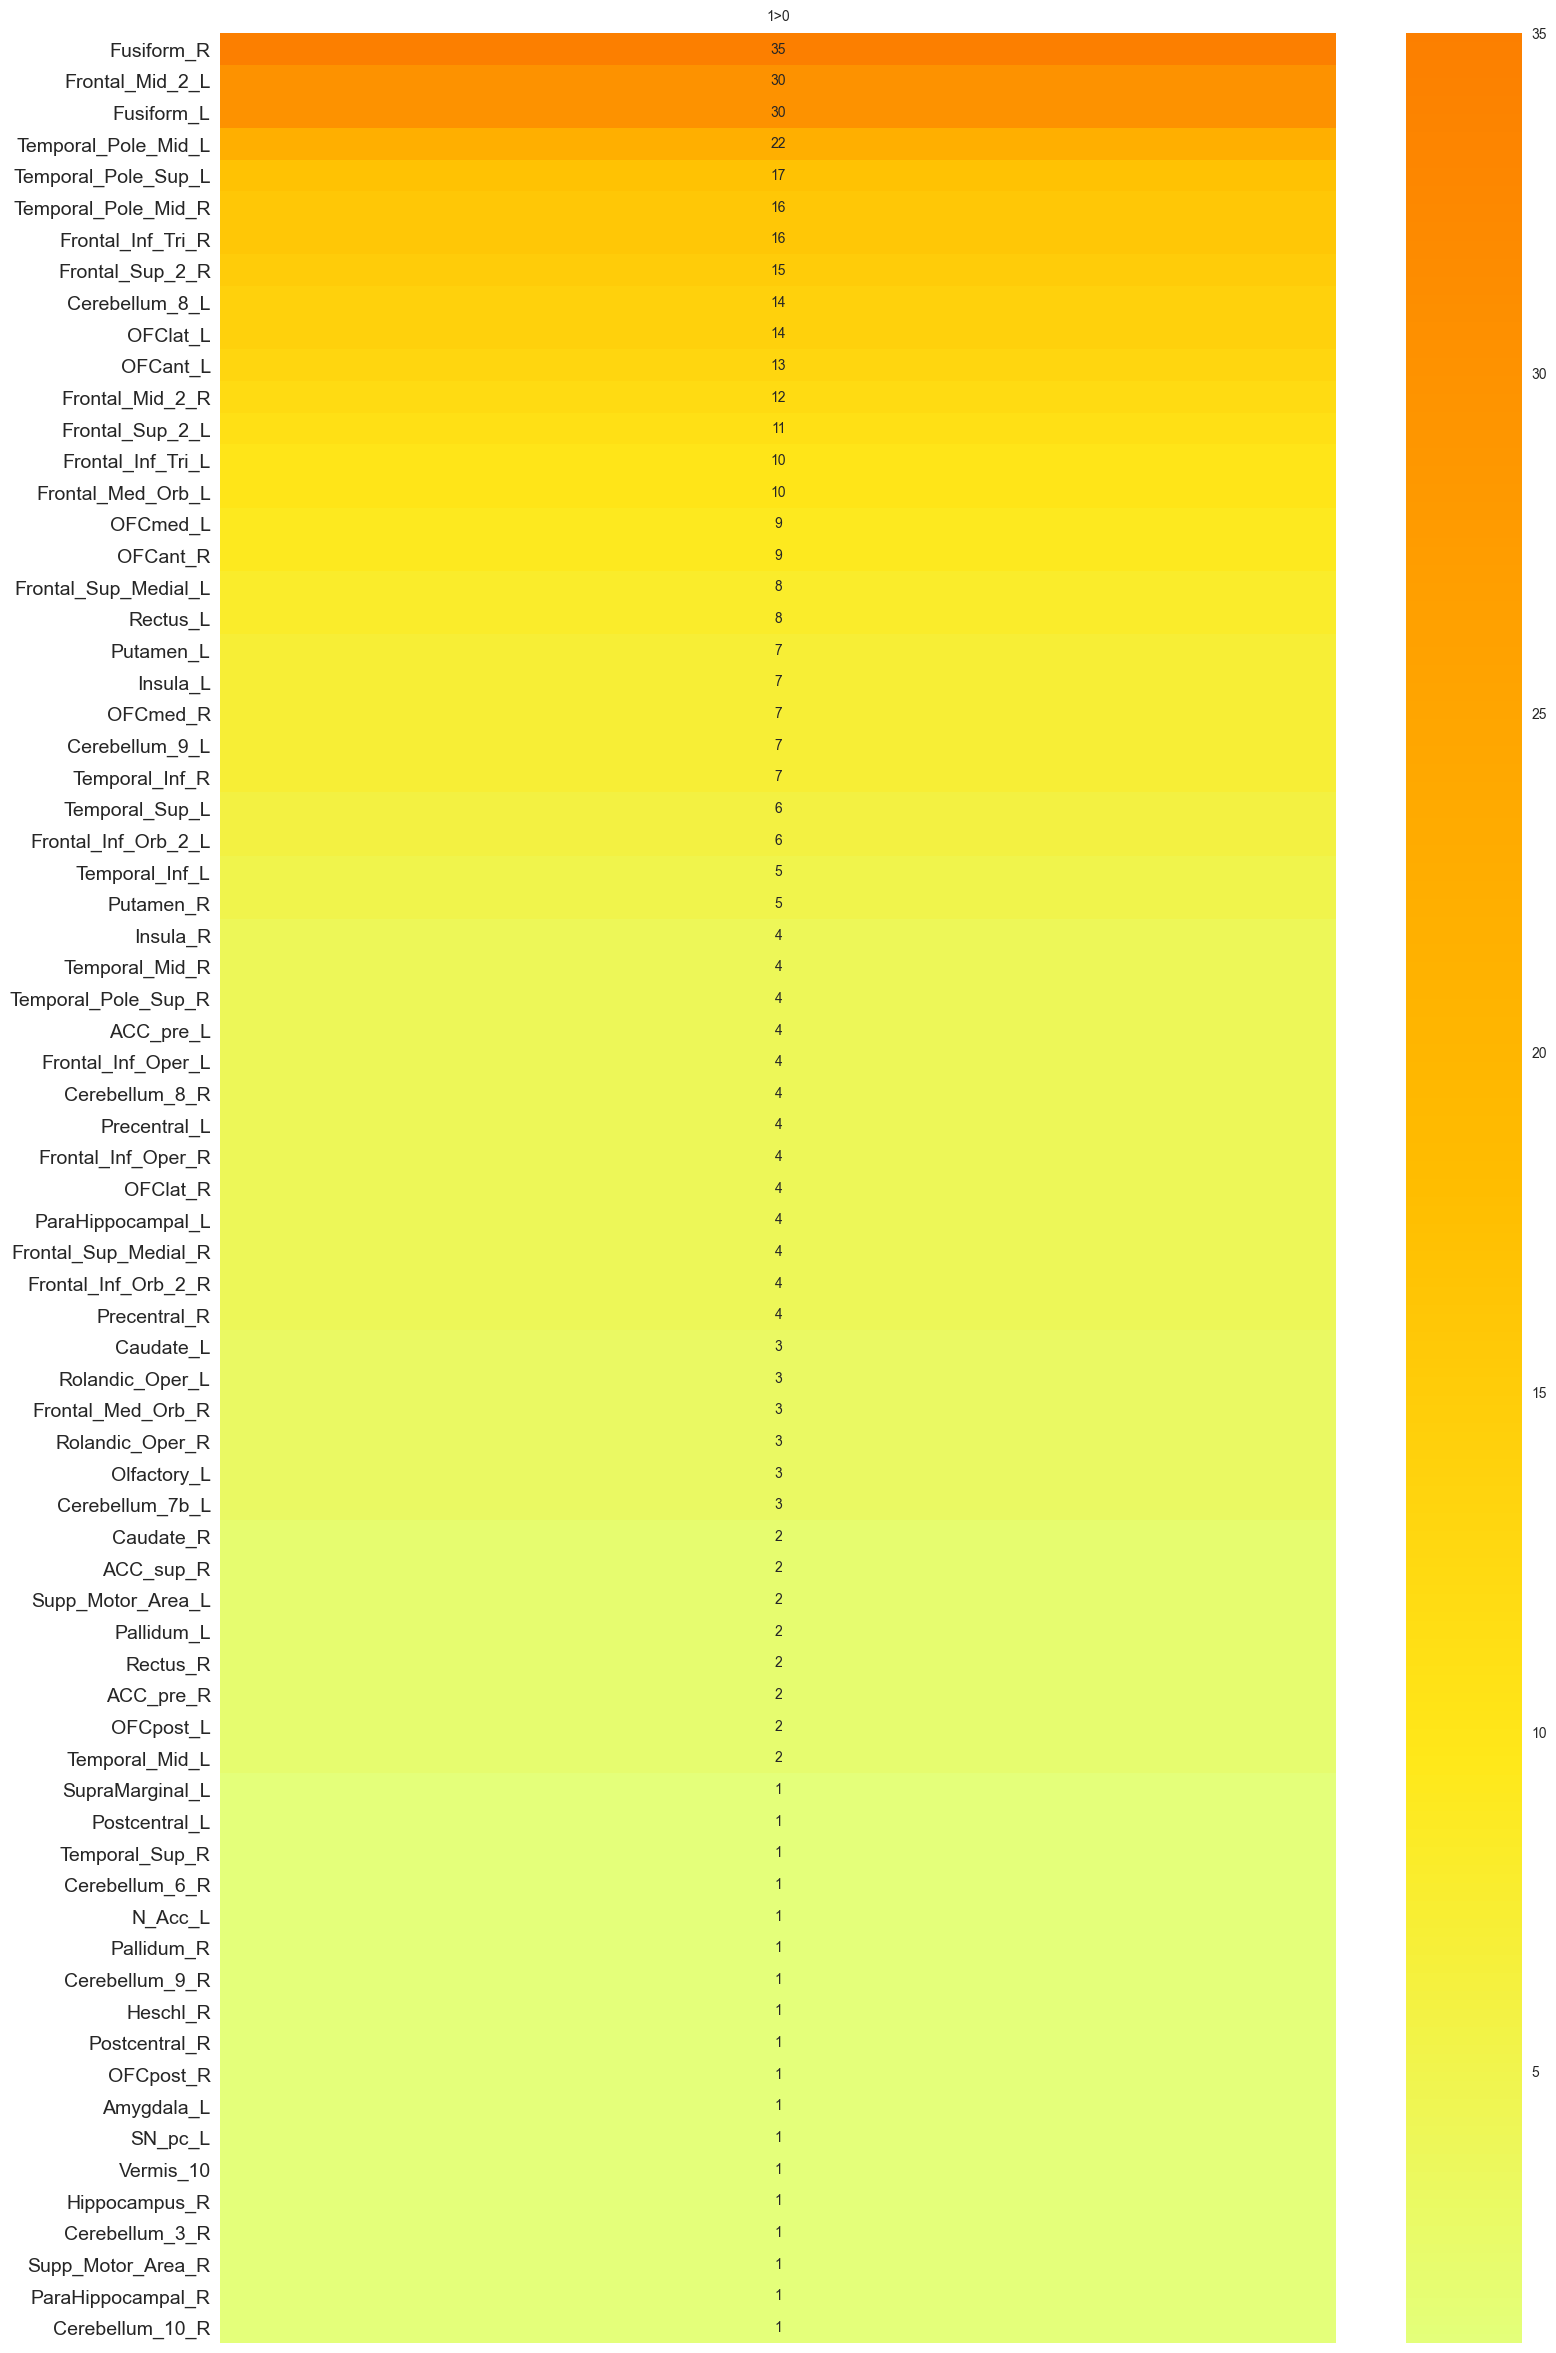

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.show()

In [ ]:
import nibabel

for contrast_name, images in global_z_map.items():

    for z_score, subject in zip(images, z_map_subjects):

        fname = contrast_name.replace(' ', '_').replace('>', 'over')

        if False:
            nibabel.save(z_score, f"contrasts/smoothed_3mm/sub-{subject}-{fname}.nii.gz")


In [10]:

subject = 12

dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
dataset.load()

images, _, _ = dataset.get_data(scale=5)

sample_mask = dataset.sample_mask

labels = pd.read_csv(f"labels/motor/labels_{subject}.csv")

"""diff = np.where(np.diff(labels["response"]) != 0)[0]
times_index = np.insert(diff, 0, 0)

values = labels["response"][diff].values
onsets = labels["response time"][times_index[:-1]].values / 1000
d_times = labels["response time"][times_index].values

durations = (d_times[1:] - d_times[:-1]) / 1000


events = pd.DataFrame(
    {'onset': onsets,
     'trial_type': values,
     'duration': durations}
)"""

events = pd.DataFrame(
    {'onset': labels["response time"].values / 1000,
     'trial_type': labels["response"].values,
     'duration': 2.5}
)

repetition_time = dataset.repetition_time
fmri_glm = FirstLevelModel(t_r=repetition_time,
          drift_model='polynomial',
          drift_order=3,
          hrf_model='spm',
          mask_img=dataset.brain_mask,
          standardize="zscore_sample",
          minimize_memory=False,
          smoothing_fwhm=4,
          n_jobs=-1)

fmri_glm = fmri_glm.fit(images, events, sample_masks=sample_mask)
# fmri_glm = fmri_glm.fit(images, events)


In [11]:

from nilearn.maskers import NiftiSpheresMasker

coords = [
    [-38, -25, 59],
    [-40, -22, 66],
    [-35, -25, 62],
    [0, 0, 0],
#    [-39, -29, 58],
    [36, -30, 62],   # right
    [47, -51, -14]   # R fusiform
]

masker = NiftiSpheresMasker(coords, verbose=1)
real_timeseries = masker.fit_transform(images)
predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])


[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015DDB217D60>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015DBFD52800>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

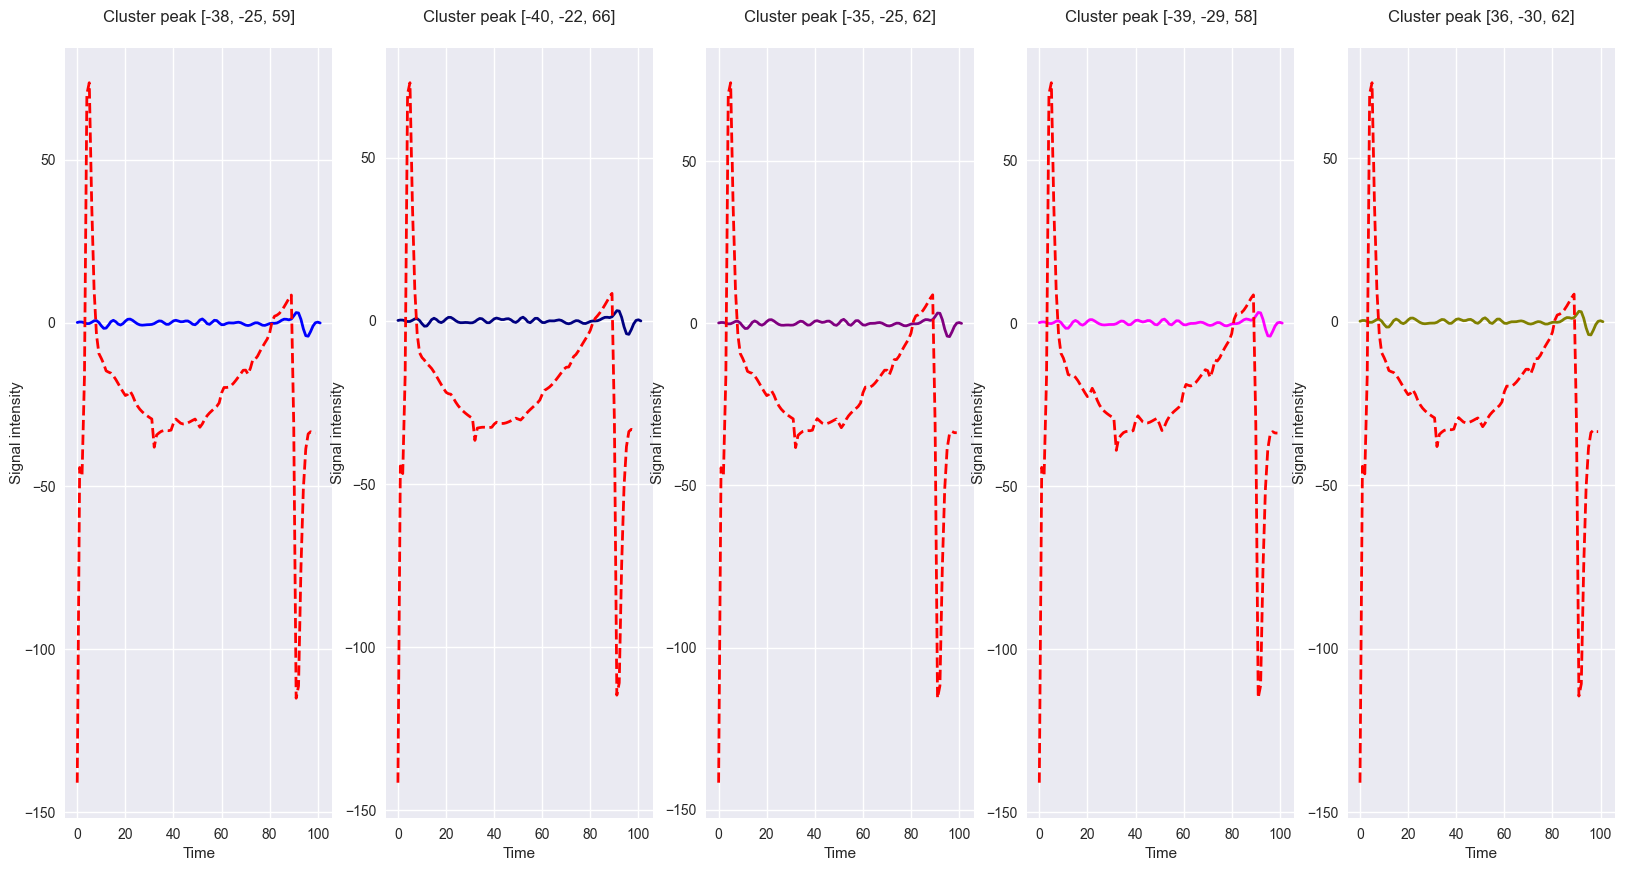

In [21]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 5, figsize=(20, 10))
for i in range(5):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)

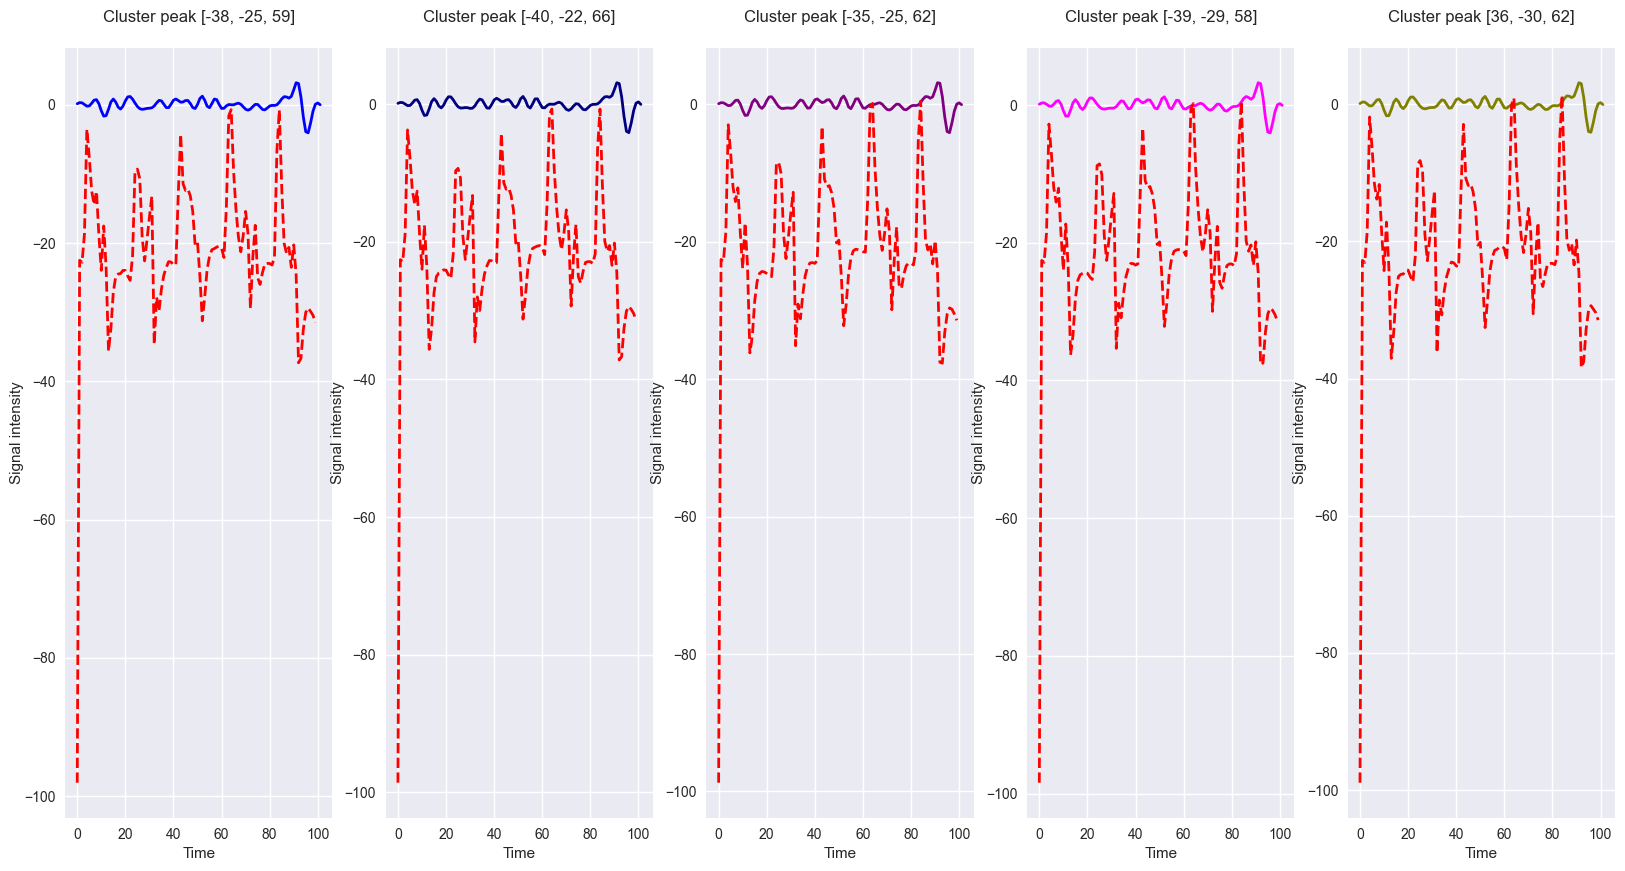

In [24]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 5, figsize=(20, 10))
for i in range(5):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)

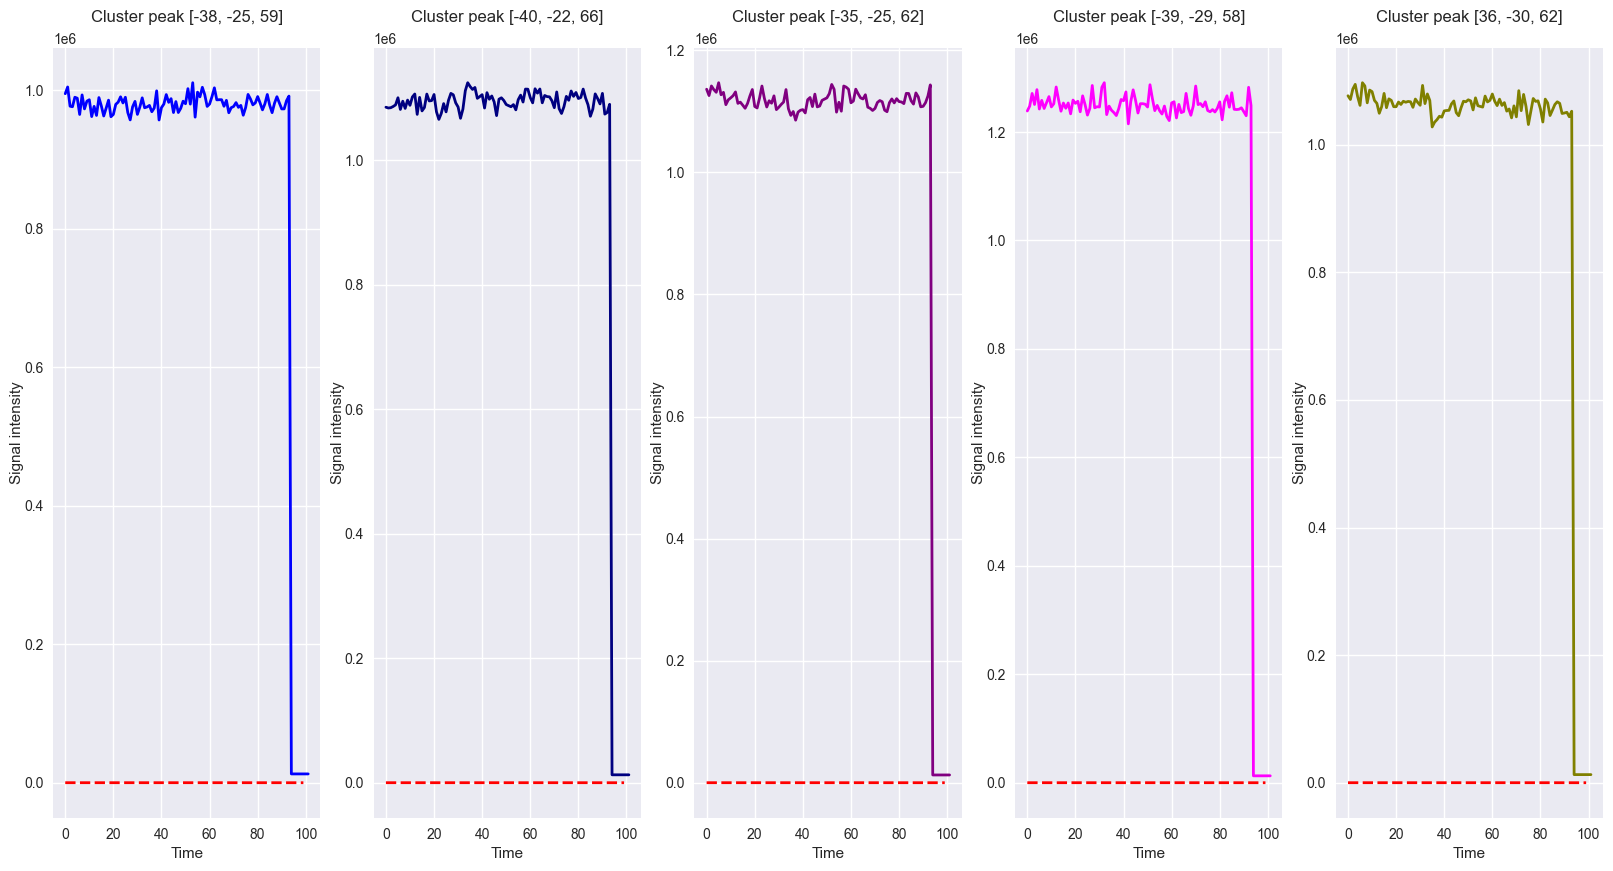

In [6]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 5, figsize=(20, 10))
for i in range(5):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)

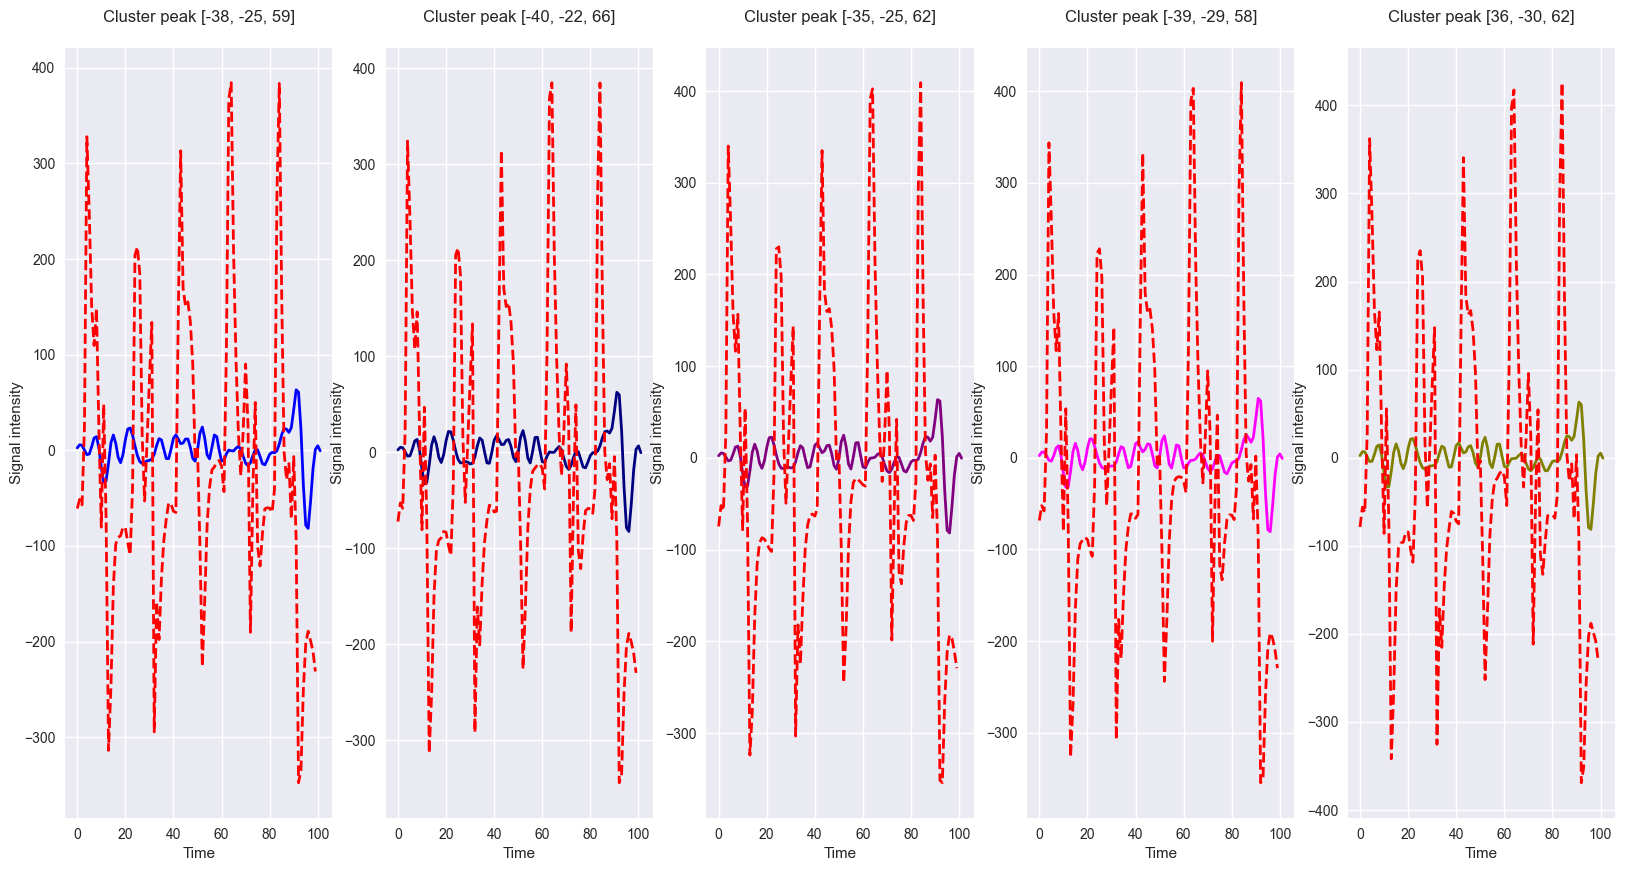

In [5]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 5, figsize=(20, 10))
for i in range(5):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)

In [8]:
for i in range(6):
    projected_coords = atlas.project_to_nearest(np.array(coords[i]))
    projected_regions = atlas.find_regions(projected_coords)
    print(coords[i], projected_regions)


[-38, -25, 59] ['Precentral_L']
[-40, -22, 66] ['Precentral_L']
[-35, -25, 62] ['Precentral_L']
[0, 0, 0] ['Thal_VA_R']
[36, -30, 62] ['Postcentral_R']
[47, -51, -14] ['Temporal_Inf_R']


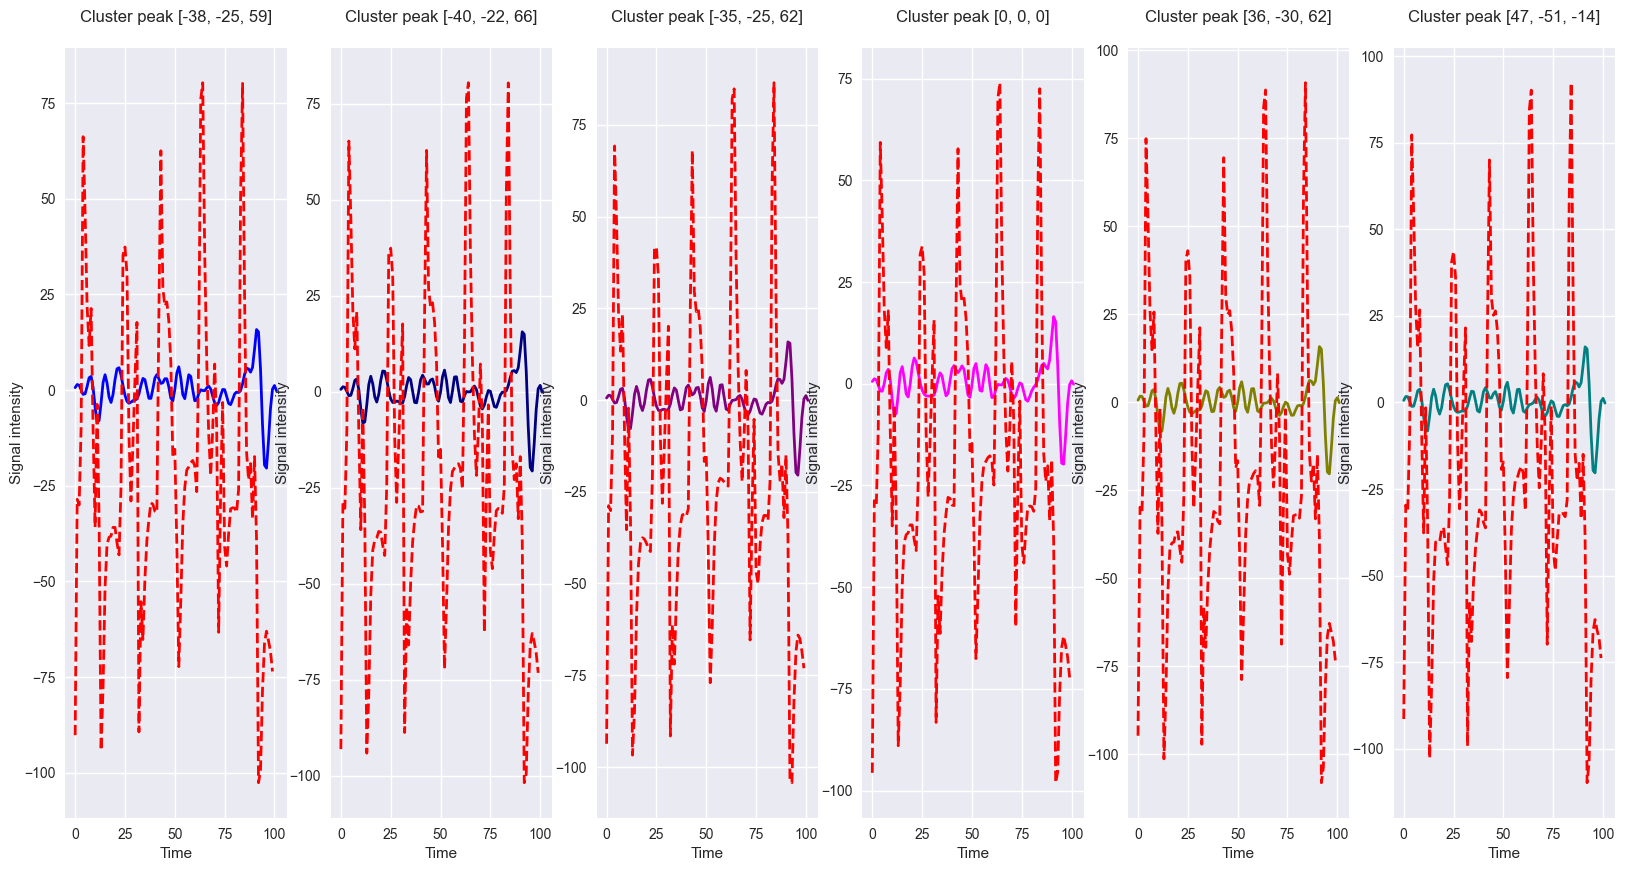

In [12]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 6, figsize=(20, 10))
for i in range(6):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)